In [1]:
import heapq
from collections import deque
import time
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from IPython.display import clear_output
import random

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
class TreasureHunt:
    
    def __init__(self, grid_size, start, treasure, obstacles=None):
        self.rows, self.cols = grid_size
        self.start = start
        self.treasure = treasure
        self.obstacles = set(obstacles) if obstacles else set()
        self.nodes_explored = 0
        self.path_length = 0
    
    def manhattan_distance(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])
    
    def get_neighbors(self, position):
        row, col = position
        neighbors = []
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        random.shuffle(directions)
        
        for dr, dc in directions:
            new_row, new_col = row + dr, col + dc
            if (0 <= new_row < self.rows and 
                0 <= new_col < self.cols and 
                (new_row, new_col) not in self.obstacles):
                neighbors.append((new_row, new_col))
        
        return neighbors
    
    def a_star_search(self):
        self.nodes_explored = 0
        counter = 0
        priority_queue = [(self.manhattan_distance(self.start, self.treasure), 
                          counter, self.start, 0, [self.start])]
        visited = set()
        
        while priority_queue:
            f_score, _, current, g_score, path = heapq.heappop(priority_queue)
            
            if current in visited:
                continue
            
            visited.add(current)
            self.nodes_explored += 1
            
            if current == self.treasure:
                self.path_length = len(path)
                return path, visited
            
            for neighbor in self.get_neighbors(current):
                if neighbor not in visited:
                    new_g_score = g_score + 1
                    h_score = self.manhattan_distance(neighbor, self.treasure)
                    new_f_score = new_g_score + h_score
                    
                    counter += 1
                    heapq.heappush(priority_queue, 
                                  (new_f_score, counter, neighbor, 
                                   new_g_score, path + [neighbor]))
        
        return None, visited
    
    def bfs_search(self):
        self.nodes_explored = 0
        queue = deque([(self.start, [self.start])])
        visited = set([self.start])
        
        while queue:
            current, path = queue.popleft()
            self.nodes_explored += 1
            
            if current == self.treasure:
                self.path_length = len(path)
                return path, visited
            
            for neighbor in self.get_neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append((neighbor, path + [neighbor]))
        
        return None, visited
    
    def dfs_search(self):
        self.nodes_explored = 0
        stack = [(self.start, [self.start])]
        visited = set()
        
        while stack:
            current, path = stack.pop()
            
            if current in visited:
                continue
            
            visited.add(current)
            self.nodes_explored += 1
            
            if current == self.treasure:
                self.path_length = len(path)
                return path, visited
            
            for neighbor in self.get_neighbors(current):
                if neighbor not in visited:
                    stack.append((neighbor, path + [neighbor]))
        
        return None, visited
    
    def visualize_search(self, path, visited, title="Search Visualization"):
        fig, ax = plt.subplots(figsize=(10, 10))
        
        for i in range(self.rows + 1):
            ax.plot([0, self.cols], [i, i], 'k-', linewidth=0.5)
        for j in range(self.cols + 1):
            ax.plot([j, j], [0, self.rows], 'k-', linewidth=0.5)
        
        for obs in self.obstacles:
            rect = Rectangle((obs[1], self.rows - obs[0] - 1), 1, 1, 
                           facecolor='black', alpha=0.7)
            ax.add_patch(rect)
        
        for cell in visited:
            if cell not in [self.start, self.treasure]:
                rect = Rectangle((cell[1], self.rows - cell[0] - 1), 1, 1, 
                               facecolor='lightblue', alpha=0.4)
                ax.add_patch(rect)
        
        if path:
            for i in range(len(path) - 1):
                current = path[i]
                next_pos = path[i + 1]
                ax.plot([current[1] + 0.5, next_pos[1] + 0.5], 
                       [self.rows - current[0] - 0.5, self.rows - next_pos[0] - 0.5], 
                       'b-', linewidth=3, marker='o', markersize=4)
        
        start_rect = Rectangle((self.start[1], self.rows - self.start[0] - 1), 1, 1, 
                              facecolor='green', alpha=0.8)
        ax.add_patch(start_rect)
        ax.text(self.start[1] + 0.5, self.rows - self.start[0] - 0.5, 'S', 
               ha='center', va='center', fontsize=16, fontweight='bold')
        
        treasure_rect = Rectangle((self.treasure[1], self.rows - self.treasure[0] - 1), 
                                 1, 1, facecolor='gold', alpha=0.8)
        ax.add_patch(treasure_rect)
        ax.text(self.treasure[1] + 0.5, self.rows - self.treasure[0] - 0.5, 'T', 
               ha='center', va='center', fontsize=16, fontweight='bold')
        
        ax.set_xlim(0, self.cols)
        ax.set_ylim(0, self.rows)
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.set_xlabel('Column', fontsize=12)
        ax.set_ylabel('Row', fontsize=12)
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', alpha=0.8, label='Start'),
            Patch(facecolor='gold', alpha=0.8, label='Treasure'),
            Patch(facecolor='lightblue', alpha=0.4, label='Explored'),
            Patch(facecolor='black', alpha=0.7, label='Obstacle')
        ]
        ax.legend(handles=legend_elements, loc='upper right')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n{'='*50}")
        print(f"Algorithm: {title}")
        print(f"{'='*50}")
        print(f"Nodes explored: {self.nodes_explored}")
        if path:
            print(f"Path length: {len(path)}")
            print(f"Path found: {' -> '.join([str(p) for p in path])}")
        else:
            print("No path found!")
        print(f"{'='*50}\n")

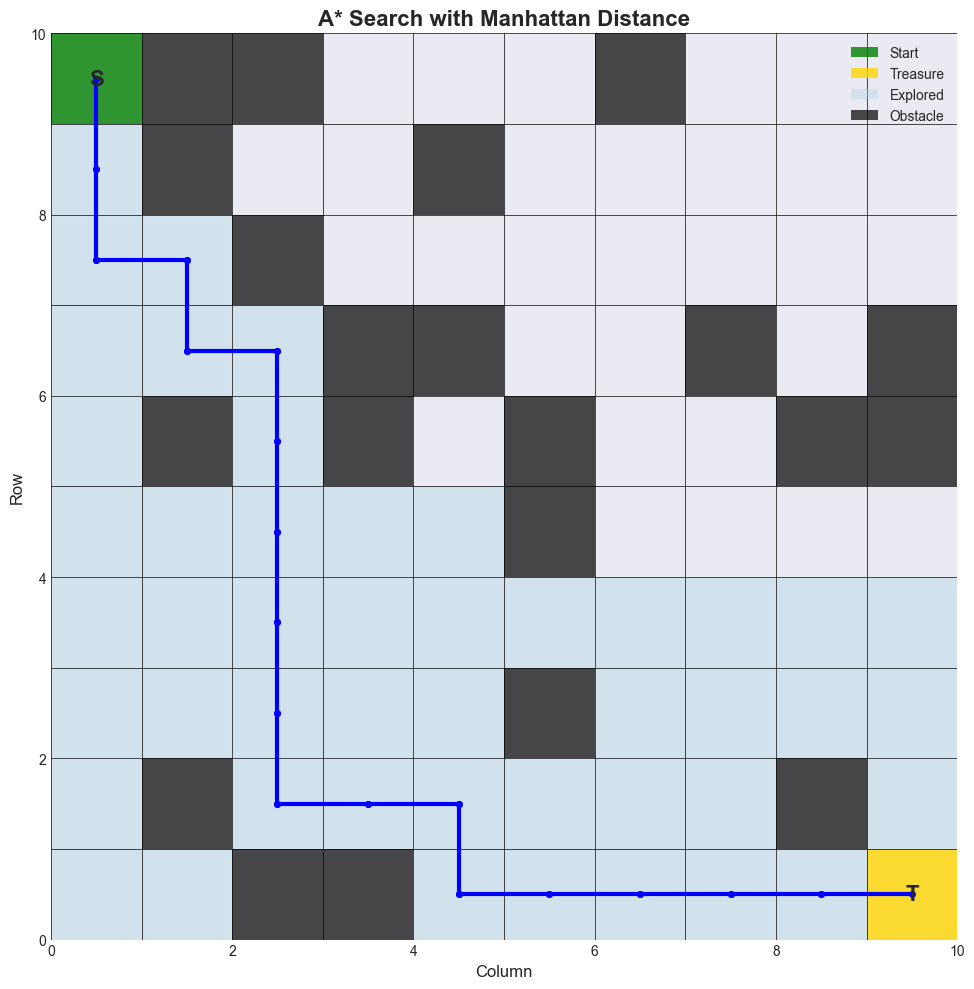


Algorithm: A* Search with Manhattan Distance
Nodes explored: 49
Path length: 19
Path found: (0, 0) -> (1, 0) -> (2, 0) -> (2, 1) -> (3, 1) -> (3, 2) -> (4, 2) -> (5, 2) -> (6, 2) -> (7, 2) -> (8, 2) -> (8, 3) -> (8, 4) -> (9, 4) -> (9, 5) -> (9, 6) -> (9, 7) -> (9, 8) -> (9, 9)



In [3]:
grid_size = (10, 10)
start = (0, 0)
treasure = (9, 9)
num_obstacles = random.randint(15, 25)
obstacles = []
while len(obstacles) < num_obstacles:
    obs = (random.randint(0, 9), random.randint(0, 9))
    if obs not in [start, treasure] and obs not in obstacles:
        obstacles.append(obs)

hunt = TreasureHunt(grid_size, start, treasure, obstacles)
path_astar, visited_astar = hunt.a_star_search()
hunt.visualize_search(path_astar, visited_astar, "A* Search with Manhattan Distance")

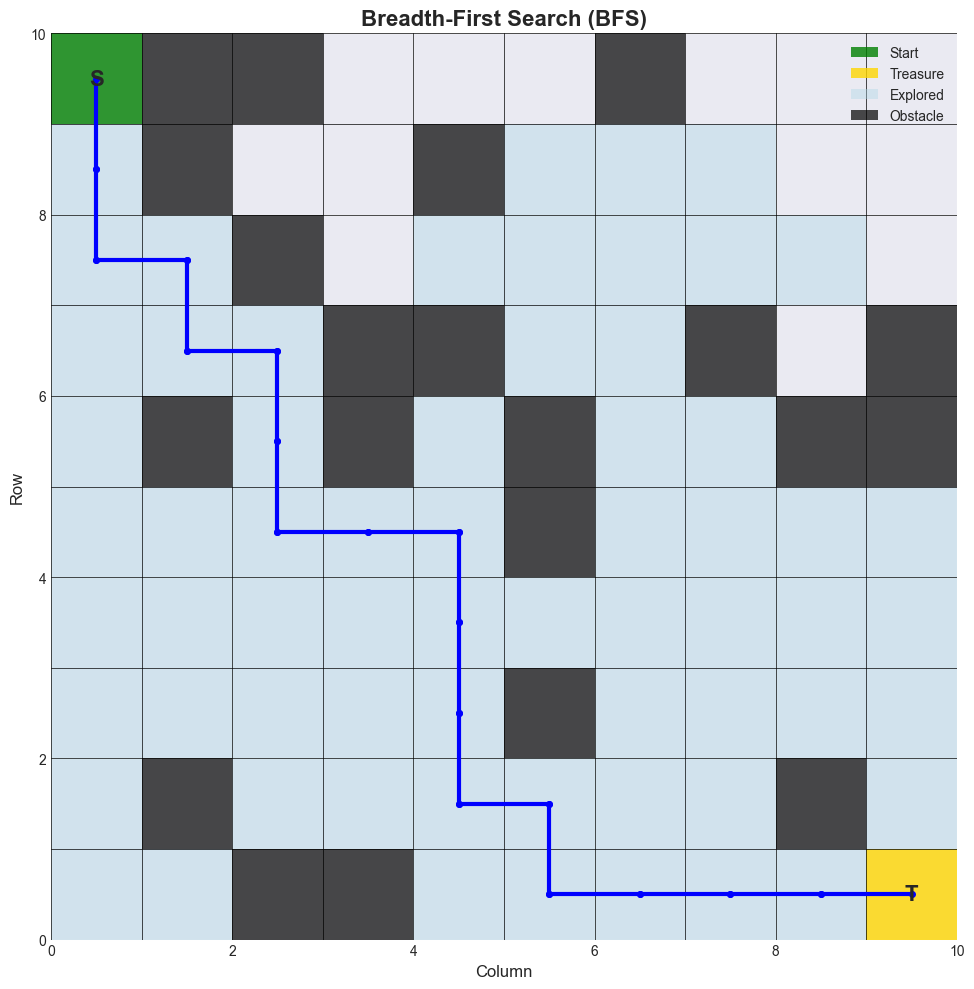


Algorithm: Breadth-First Search (BFS)
Nodes explored: 62
Path length: 19
Path found: (0, 0) -> (1, 0) -> (2, 0) -> (2, 1) -> (3, 1) -> (3, 2) -> (4, 2) -> (5, 2) -> (5, 3) -> (5, 4) -> (6, 4) -> (7, 4) -> (8, 4) -> (8, 5) -> (9, 5) -> (9, 6) -> (9, 7) -> (9, 8) -> (9, 9)



In [4]:
hunt_bfs = TreasureHunt(grid_size, start, treasure, obstacles)
path_bfs, visited_bfs = hunt_bfs.bfs_search()
hunt_bfs.visualize_search(path_bfs, visited_bfs, "Breadth-First Search (BFS)")

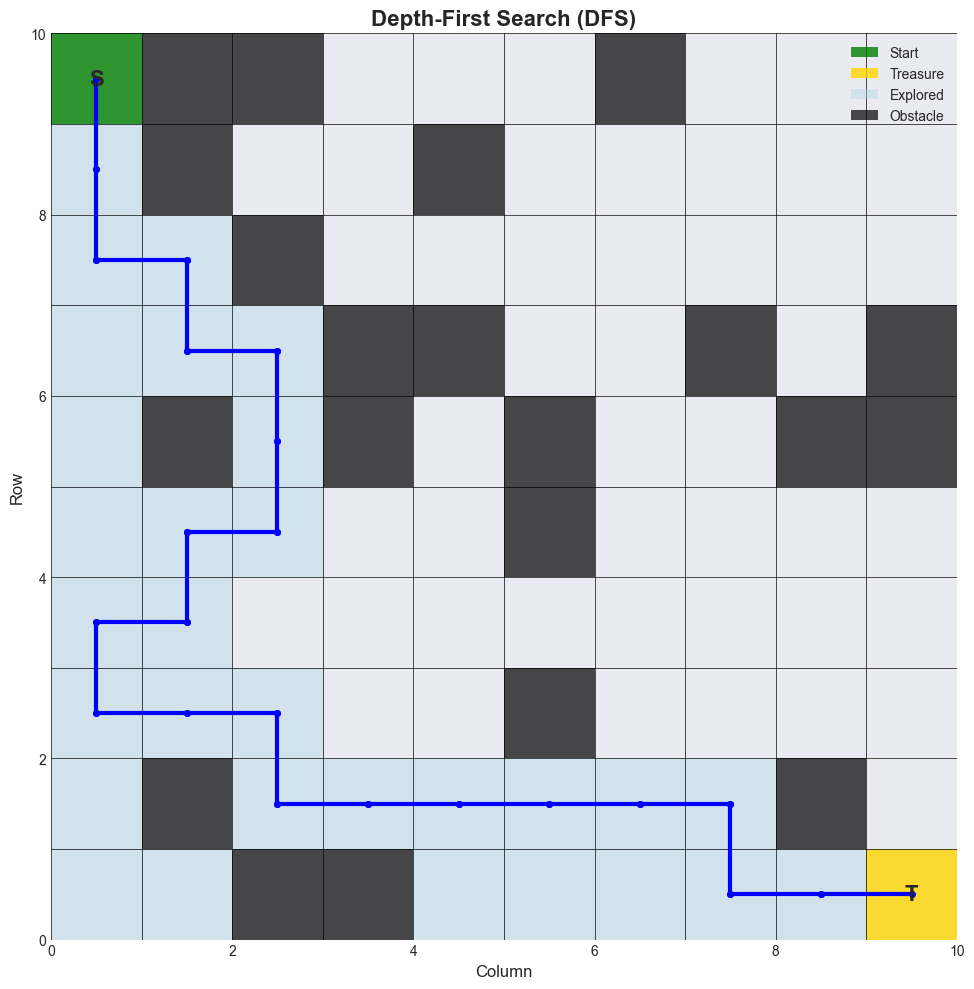


Algorithm: Depth-First Search (DFS)
Nodes explored: 32
Path length: 23
Path found: (0, 0) -> (1, 0) -> (2, 0) -> (2, 1) -> (3, 1) -> (3, 2) -> (4, 2) -> (5, 2) -> (5, 1) -> (6, 1) -> (6, 0) -> (7, 0) -> (7, 1) -> (7, 2) -> (8, 2) -> (8, 3) -> (8, 4) -> (8, 5) -> (8, 6) -> (8, 7) -> (9, 7) -> (9, 8) -> (9, 9)



In [5]:
hunt_dfs = TreasureHunt(grid_size, start, treasure, obstacles)
path_dfs, visited_dfs = hunt_dfs.dfs_search()
hunt_dfs.visualize_search(path_dfs, visited_dfs, "Depth-First Search (DFS)")

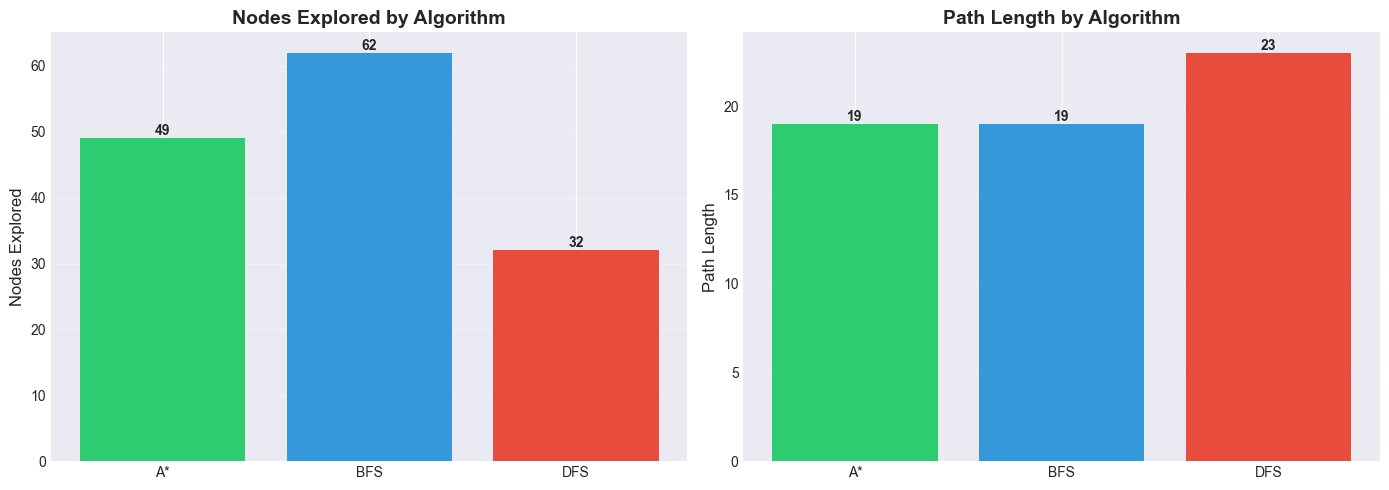


PERFORMANCE ANALYSIS

Algorithm       Nodes Explored       Path Length    
------------------------------------------------------------
A*              49                   19             
BFS             62                   19             
DFS             32                   23             

Key Observations:
- A* explores fewer nodes due to heuristic guidance
- BFS guarantees shortest path but explores more nodes
- DFS may find longer paths and explore unnecessarily


In [6]:
algorithms = ['A*', 'BFS', 'DFS']
nodes_explored = [
    hunt.nodes_explored,
    hunt_bfs.nodes_explored,
    hunt_dfs.nodes_explored
]
path_lengths = [
    len(path_astar) if path_astar else 0,
    len(path_bfs) if path_bfs else 0,
    len(path_dfs) if path_dfs else 0
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(algorithms, nodes_explored, color=['#2ecc71', '#3498db', '#e74c3c'])
ax1.set_ylabel('Nodes Explored', fontsize=12)
ax1.set_title('Nodes Explored by Algorithm', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(algorithms, path_lengths, color=['#2ecc71', '#3498db', '#e74c3c'])
ax2.set_ylabel('Path Length', fontsize=12)
ax2.set_title('Path Length by Algorithm', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PERFORMANCE ANALYSIS")
print("="*60)
print(f"\n{'Algorithm':<15} {'Nodes Explored':<20} {'Path Length':<15}")
print("-"*60)
for algo, nodes, path_len in zip(algorithms, nodes_explored, path_lengths):
    print(f"{algo:<15} {nodes:<20} {path_len:<15}")
print("="*60)
print("\nKey Observations:")
print("- A* explores fewer nodes due to heuristic guidance")
print("- BFS guarantees shortest path but explores more nodes")
print("- DFS may find longer paths and explore unnecessarily")
print("="*60)

In [7]:
class PuzzleState:
    
    def __init__(self, board, parent=None, move=None, depth=0):
        self.board = board
        self.parent = parent
        self.move = move
        self.depth = depth
        self.blank_pos = board.index(0)
    
    def __eq__(self, other):
        return self.board == other.board
    
    def __hash__(self):
        return hash(tuple(self.board))
    
    def __lt__(self, other):
        return False
    
    def get_position(self, index):
        return (index // 3, index % 3)
    
    def get_index(self, row, col):
        return row * 3 + col
    
    def get_neighbors(self):
        neighbors = []
        row, col = self.get_position(self.blank_pos)
        
        moves = [
            (-1, 0, 'Up'),
            (1, 0, 'Down'),
            (0, -1, 'Left'),
            (0, 1, 'Right')
        ]
        random.shuffle(moves)
        
        for dr, dc, move_name in moves:
            new_row, new_col = row + dr, col + dc
            
            if 0 <= new_row < 3 and 0 <= new_col < 3:
                new_board = self.board.copy()
                new_index = self.get_index(new_row, new_col)
                
                new_board[self.blank_pos], new_board[new_index] = \
                    new_board[new_index], new_board[self.blank_pos]
                
                neighbors.append(PuzzleState(new_board, self, move_name, 
                                            self.depth + 1))
        
        return neighbors
    
    def get_path(self):
        path = []
        current = self
        while current.parent is not None:
            path.append((current.move, current.board))
            current = current.parent
        path.reverse()
        return path
    
    def display(self):
        for i in range(0, 9, 3):
            row = self.board[i:i+3]
            print(' '.join(['_' if x == 0 else str(x) for x in row]))
        print()

In [8]:
class PuzzleSolver:
    
    def __init__(self, start_state, goal_state=None):
        self.start = PuzzleState(start_state)
        self.goal = goal_state if goal_state else [1, 2, 3, 4, 5, 6, 7, 8, 0]
        self.nodes_explored = 0
    
    def is_solvable(self, board):
        inversions = 0
        board_without_blank = [x for x in board if x != 0]
        
        for i in range(len(board_without_blank)):
            for j in range(i + 1, len(board_without_blank)):
                if board_without_blank[i] > board_without_blank[j]:
                    inversions += 1
        
        return inversions % 2 == 0
    
    def manhattan_distance(self, state):
        distance = 0
        for i in range(9):
            if state.board[i] != 0:
                current_row, current_col = state.get_position(i)
                goal_index = self.goal.index(state.board[i])
                goal_row, goal_col = state.get_position(goal_index)
                distance += abs(current_row - goal_row) + abs(current_col - goal_col)
        return distance
    
    def misplaced_tiles(self, state):
        return sum(1 for i in range(9) 
                  if state.board[i] != 0 and state.board[i] != self.goal[i])
    
    def a_star_search(self, heuristic='manhattan'):
        if not self.is_solvable(self.start.board):
            print("This puzzle configuration is UNSOLVABLE!")
            return None
        
        h_func = self.manhattan_distance if heuristic == 'manhattan' else self.misplaced_tiles
        
        self.nodes_explored = 0
        counter = 0
        
        h_start = h_func(self.start)
        priority_queue = [(h_start, counter, self.start)]
        visited = set()
        
        while priority_queue:
            f_score, _, current = heapq.heappop(priority_queue)
            
            if current in visited:
                continue
            
            visited.add(current)
            self.nodes_explored += 1
            
            if current.board == self.goal:
                return current.get_path()
            
            for neighbor in current.get_neighbors():
                if neighbor not in visited:
                    g_score = neighbor.depth
                    h_score = h_func(neighbor)
                    f_score = g_score + h_score
                    
                    counter += 1
                    heapq.heappush(priority_queue, (f_score, counter, neighbor))
        
        return None
    
    def visualize_solution(self, solution, heuristic_name):
        if solution is None:
            print("No solution to visualize!")
            return
        
        num_steps = len(solution)
        
        cols = min(5, num_steps + 1)
        rows = (num_steps + 1 + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        ax_idx = 0
        row_idx = ax_idx // cols
        col_idx = ax_idx % cols
        self._draw_puzzle(axes[row_idx, col_idx], self.start.board, "Start")
        
        for idx, (move, board) in enumerate(solution):
            ax_idx = idx + 1
            row_idx = ax_idx // cols
            col_idx = ax_idx % cols
            self._draw_puzzle(axes[row_idx, col_idx], board, f"{idx+1}. {move}")
        
        for ax_idx in range(num_steps + 1, rows * cols):
            row_idx = ax_idx // cols
            col_idx = ax_idx % cols
            axes[row_idx, col_idx].axis('off')
        
        fig.suptitle(f'8-Puzzle Solution using A* ({heuristic_name.title()} Heuristic)', 
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"\n{'='*60}")
        print(f"Solution found using {heuristic_name.upper()} heuristic")
        print(f"{'='*60}")
        print(f"Nodes explored: {self.nodes_explored}")
        print(f"Solution length: {num_steps} moves")
        print(f"Moves: {' -> '.join([move for move, _ in solution])}")
        print(f"{'='*60}\n")
    
    def _draw_puzzle(self, ax, board, title):
        ax.clear()
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 3)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=10, fontweight='bold')
        
        for i in range(3):
            for j in range(3):
                idx = i * 3 + j
                tile_value = board[idx]
                
                if tile_value == 0:
                    color = 'white'
                    text = ''
                else:
                    color = 'lightblue'
                    text = str(tile_value)
                
                rect = Rectangle((j, 2-i), 1, 1, 
                                facecolor=color, edgecolor='black', linewidth=2)
                ax.add_patch(rect)
                
                if text:
                    ax.text(j + 0.5, 2-i + 0.5, text, 
                           ha='center', va='center', 
                           fontsize=20, fontweight='bold')

Starting configuration:
_ 7 6
5 4 3
1 2 8



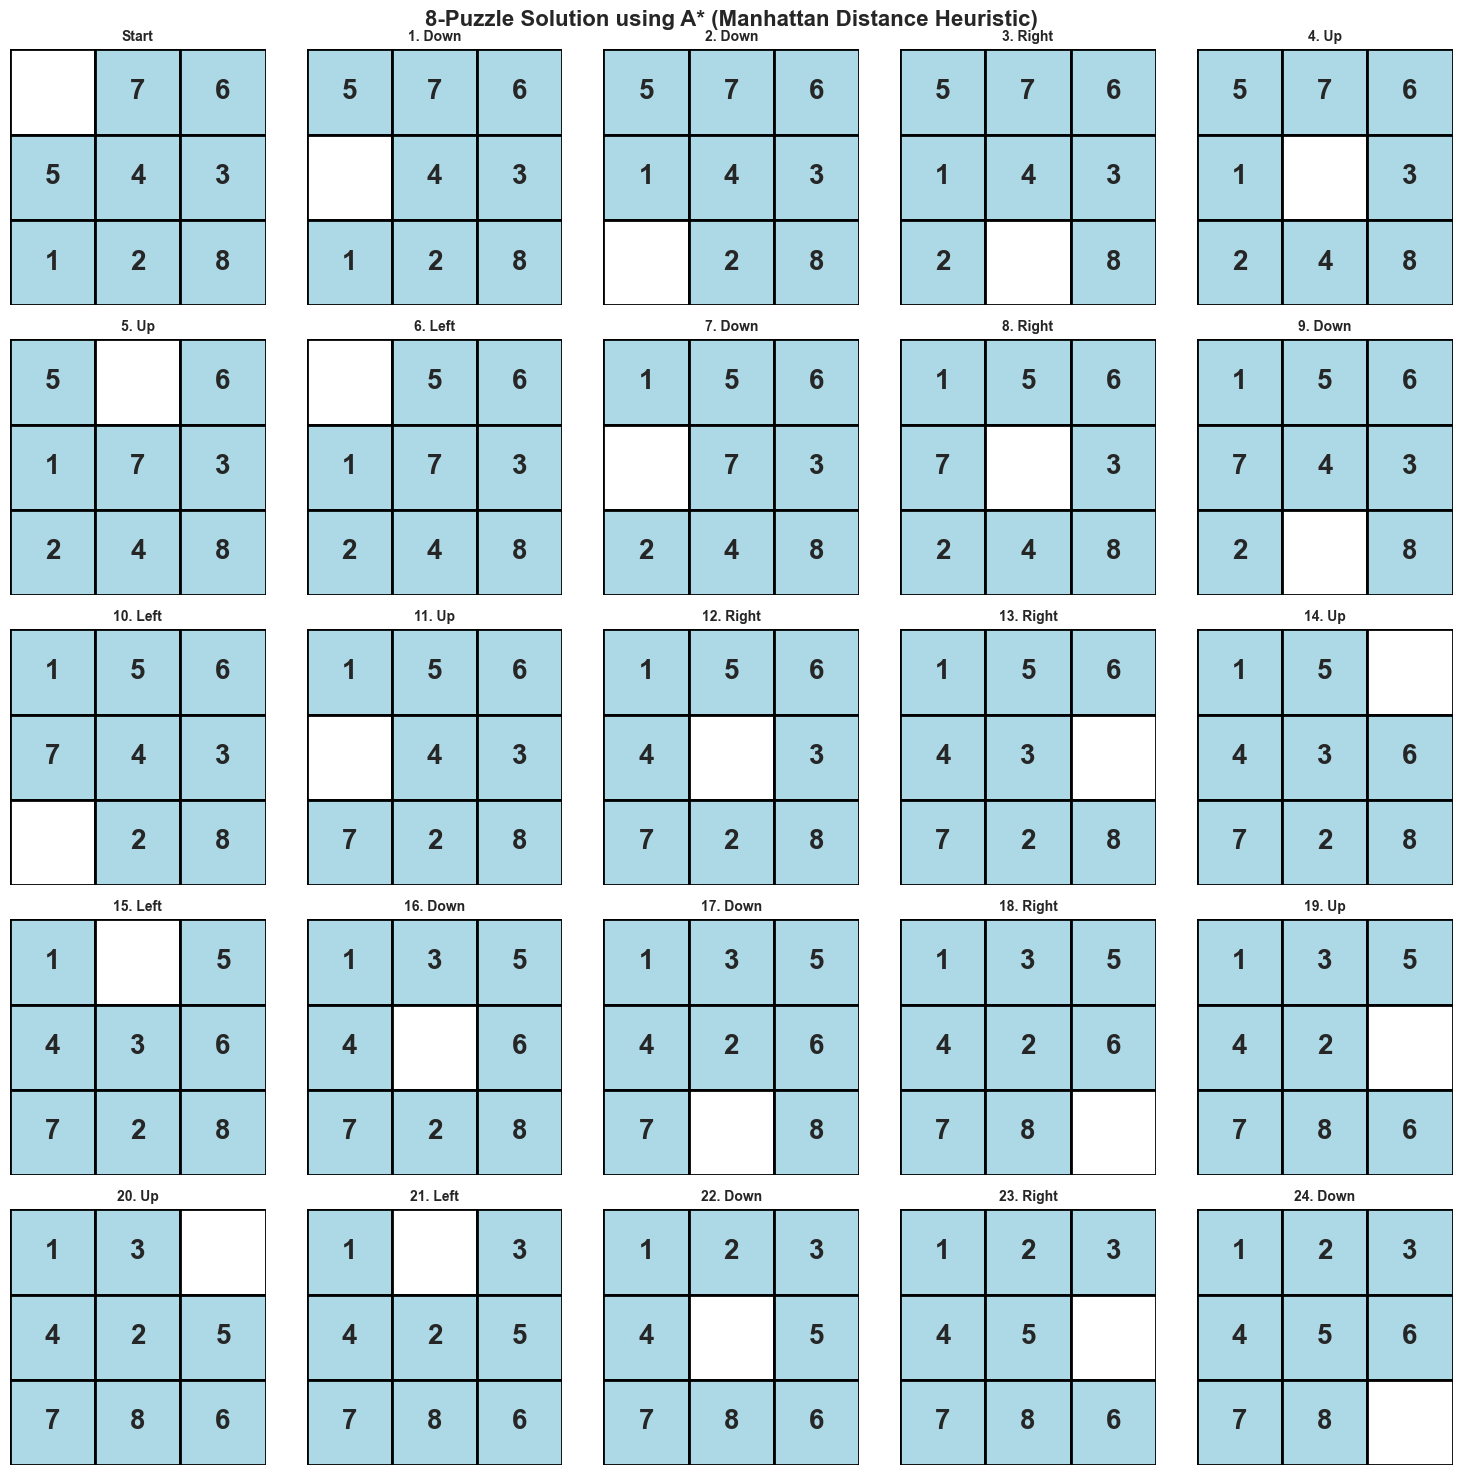


Solution found using MANHATTAN DISTANCE heuristic
Nodes explored: 2599
Solution length: 24 moves
Moves: Down -> Down -> Right -> Up -> Up -> Left -> Down -> Right -> Down -> Left -> Up -> Right -> Right -> Up -> Left -> Down -> Down -> Right -> Up -> Up -> Left -> Down -> Right -> Down



In [9]:
def generate_random_puzzle():
    while True:
        tiles = list(range(9))
        random.shuffle(tiles)
        solver = PuzzleSolver(tiles)
        if solver.is_solvable(tiles):
            return tiles

puzzle_config = generate_random_puzzle()

print("Starting configuration:")
PuzzleState(puzzle_config).display()

solver_manhattan = PuzzleSolver(puzzle_config)
solution_manhattan = solver_manhattan.a_star_search('manhattan')
solver_manhattan.visualize_solution(solution_manhattan, 'Manhattan Distance')

Starting configuration:
2 6 8
5 7 4
1 3 _



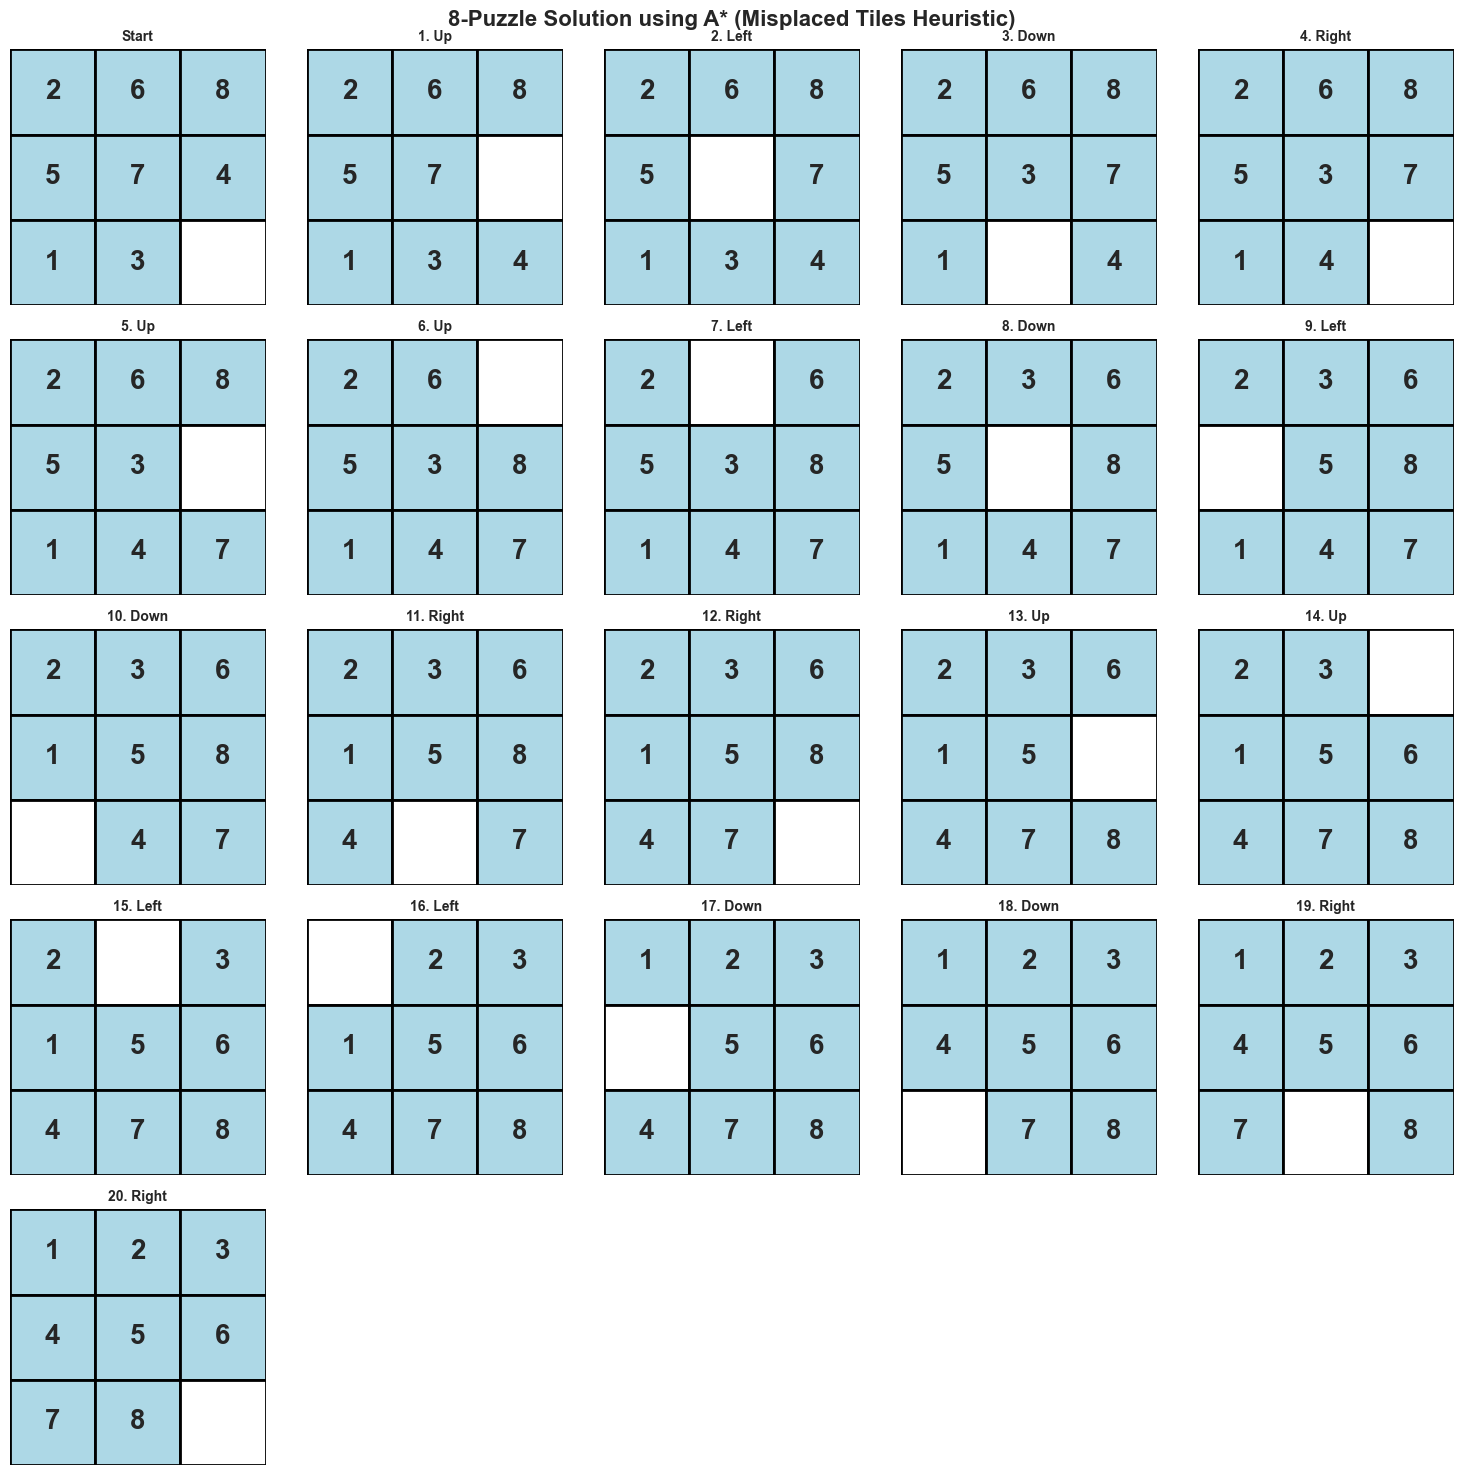


Solution found using MISPLACED TILES heuristic
Nodes explored: 2916
Solution length: 20 moves
Moves: Up -> Left -> Down -> Right -> Up -> Up -> Left -> Down -> Left -> Down -> Right -> Right -> Up -> Up -> Left -> Left -> Down -> Down -> Right -> Right



In [10]:
puzzle_config_2 = generate_random_puzzle()

print("Starting configuration:")
PuzzleState(puzzle_config_2).display()

solver_misplaced = PuzzleSolver(puzzle_config_2)
solution_misplaced = solver_misplaced.a_star_search('misplaced')
solver_misplaced.visualize_solution(solution_misplaced, 'Misplaced Tiles')

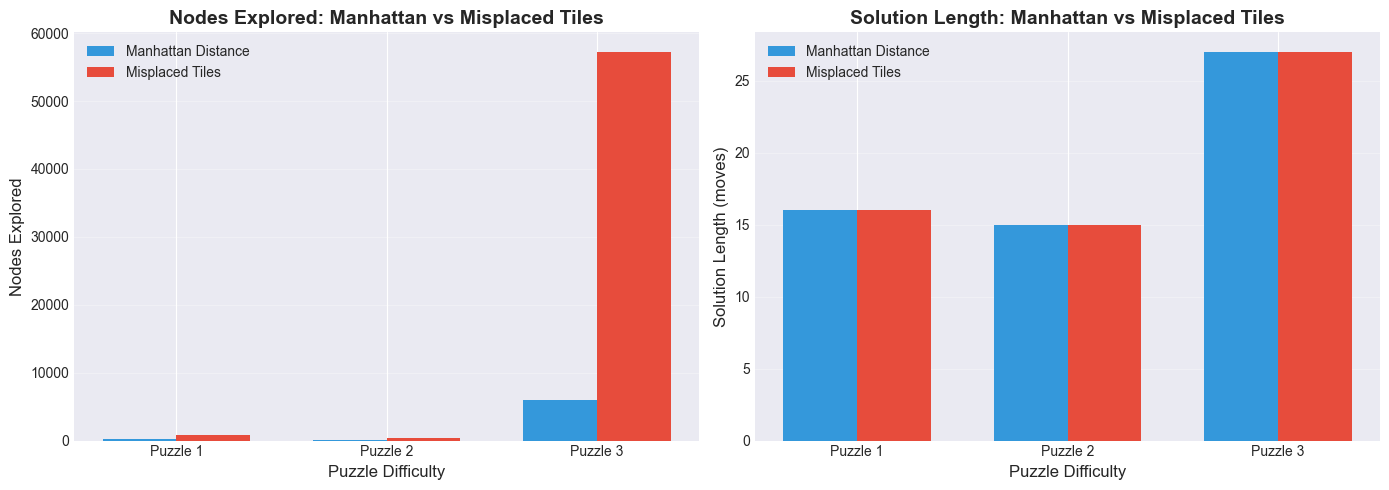


HEURISTIC COMPARISON: MANHATTAN DISTANCE vs MISPLACED TILES

Puzzle       Manhattan Nodes    Misplaced Nodes    Manhattan Moves    Misplaced Moves   
--------------------------------------------------------------------------------
Puzzle 1     219                773                16                 16                
Puzzle 2     45                 371                15                 15                
Puzzle 3     5930               57256              27                 27                

Key Insights:
1. Manhattan Distance is more informed - explores fewer nodes
2. Both find optimal solutions (same path length)
3. Manhattan Distance is generally more efficient for 8-puzzle
4. Performance gap increases with puzzle difficulty


In [11]:
test_puzzles = [generate_random_puzzle() for _ in range(3)]

results = {
    'puzzle': [],
    'manhattan_nodes': [],
    'misplaced_nodes': [],
    'manhattan_moves': [],
    'misplaced_moves': []
}

for idx, puzzle in enumerate(test_puzzles):
    solver_m = PuzzleSolver(puzzle)
    solution_m = solver_m.a_star_search('manhattan')
    
    solver_p = PuzzleSolver(puzzle)
    solution_p = solver_p.a_star_search('misplaced')
    
    results['puzzle'].append(f"Puzzle {idx+1}")
    results['manhattan_nodes'].append(solver_m.nodes_explored)
    results['misplaced_nodes'].append(solver_p.nodes_explored)
    results['manhattan_moves'].append(len(solution_m) if solution_m else 0)
    results['misplaced_moves'].append(len(solution_p) if solution_p else 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(results['puzzle']))
width = 0.35

ax1.bar(x - width/2, results['manhattan_nodes'], width, 
        label='Manhattan Distance', color='#3498db')
ax1.bar(x + width/2, results['misplaced_nodes'], width, 
        label='Misplaced Tiles', color='#e74c3c')
ax1.set_xlabel('Puzzle Difficulty', fontsize=12)
ax1.set_ylabel('Nodes Explored', fontsize=12)
ax1.set_title('Nodes Explored: Manhattan vs Misplaced Tiles', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results['puzzle'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2.bar(x - width/2, results['manhattan_moves'], width, 
        label='Manhattan Distance', color='#3498db')
ax2.bar(x + width/2, results['misplaced_moves'], width, 
        label='Misplaced Tiles', color='#e74c3c')
ax2.set_xlabel('Puzzle Difficulty', fontsize=12)
ax2.set_ylabel('Solution Length (moves)', fontsize=12)
ax2.set_title('Solution Length: Manhattan vs Misplaced Tiles', 
              fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results['puzzle'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HEURISTIC COMPARISON: MANHATTAN DISTANCE vs MISPLACED TILES")
print("="*80)
print(f"\n{'Puzzle':<12} {'Manhattan Nodes':<18} {'Misplaced Nodes':<18} {'Manhattan Moves':<18} {'Misplaced Moves':<18}")
print("-"*80)
for i, puzzle in enumerate(results['puzzle']):
    print(f"{puzzle:<12} {results['manhattan_nodes'][i]:<18} {results['misplaced_nodes'][i]:<18} "
          f"{results['manhattan_moves'][i]:<18} {results['misplaced_moves'][i]:<18}")
print("="*80)
print("\nKey Insights:")
print("1. Manhattan Distance is more informed - explores fewer nodes")
print("2. Both find optimal solutions (same path length)")
print("3. Manhattan Distance is generally more efficient for 8-puzzle")
print("4. Performance gap increases with puzzle difficulty")
print("="*80)

Your custom puzzle:
7 2 4
5 _ 6
8 3 1

This puzzle is SOLVABLE! Finding solution...



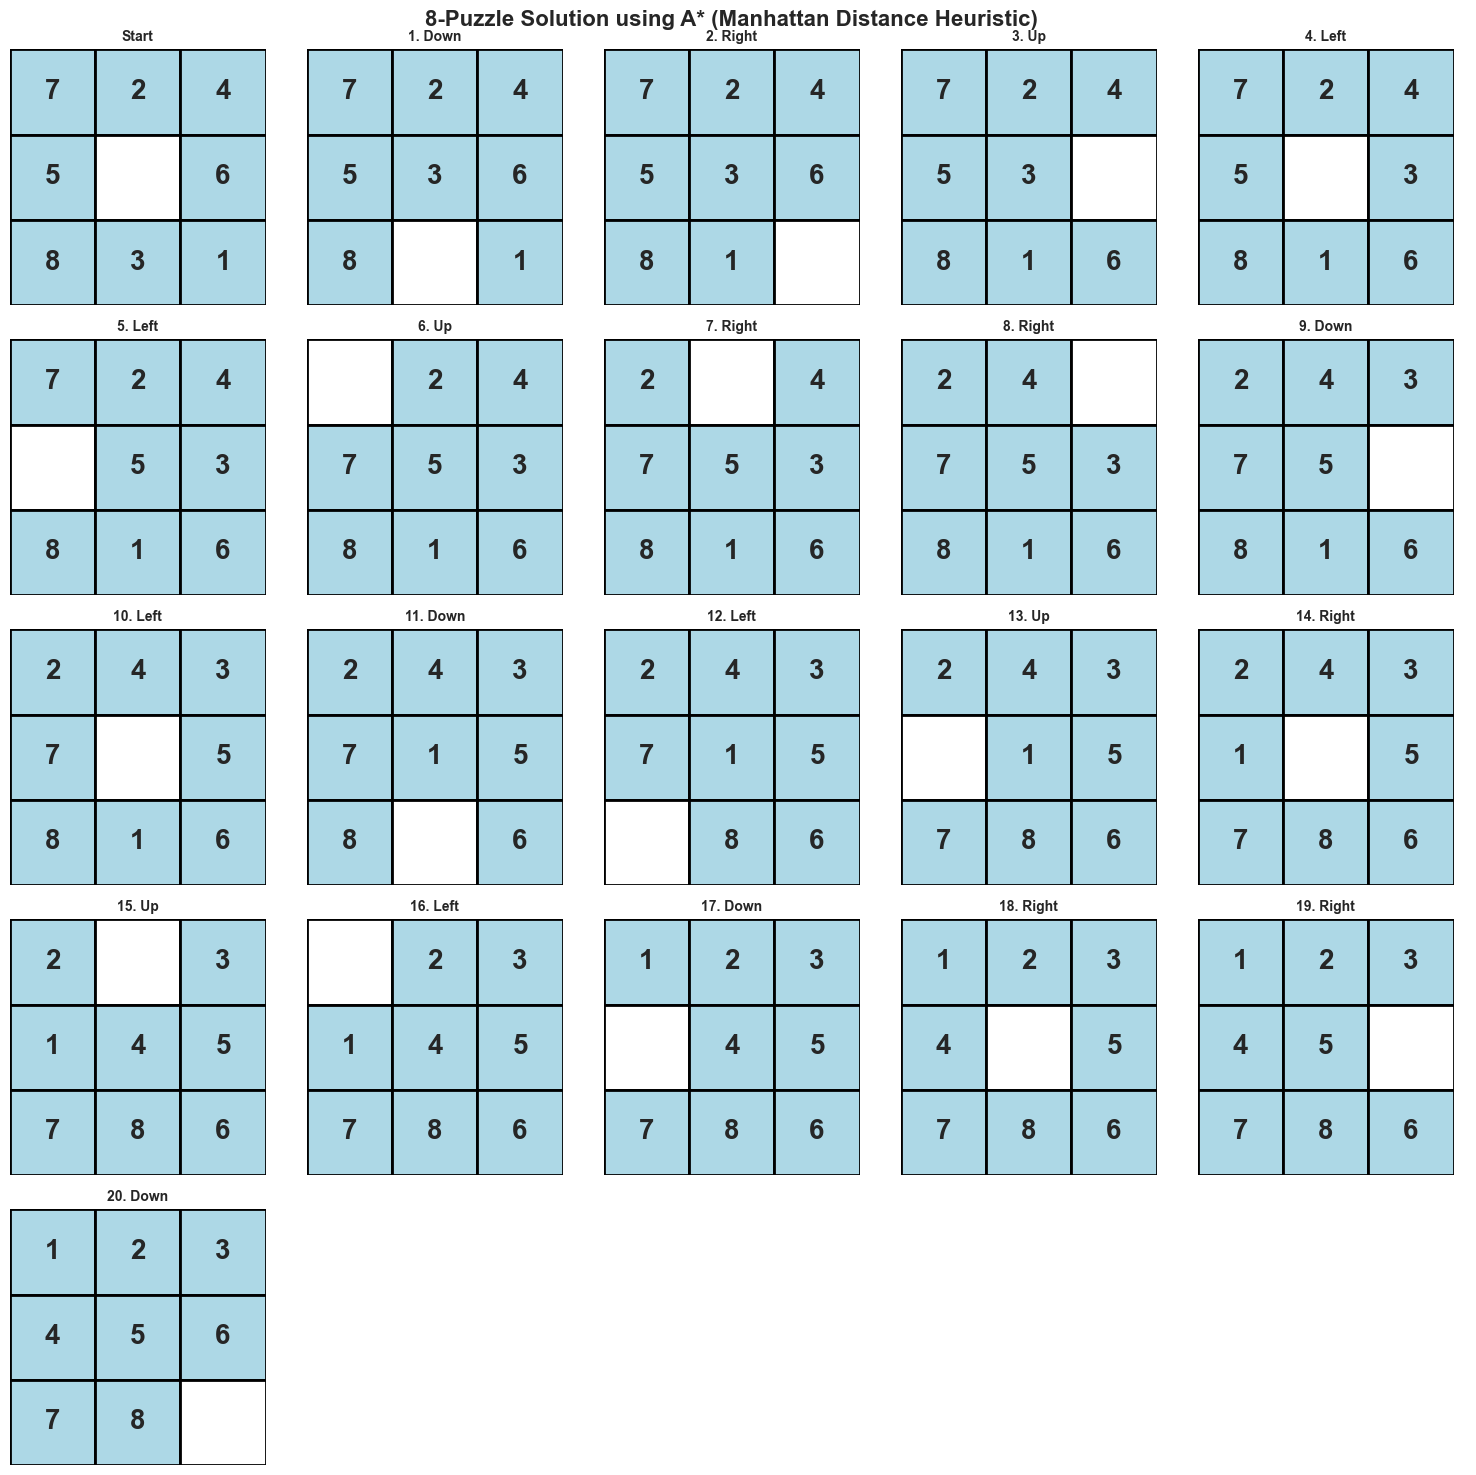


Solution found using MANHATTAN DISTANCE heuristic
Nodes explored: 283
Solution length: 20 moves
Moves: Down -> Right -> Up -> Left -> Left -> Up -> Right -> Right -> Down -> Left -> Down -> Left -> Up -> Right -> Up -> Left -> Down -> Right -> Right -> Down



In [12]:
custom_puzzle = [7, 2, 4, 5, 0, 6, 8, 3, 1]

print("Your custom puzzle:")
PuzzleState(custom_puzzle).display()

custom_solver = PuzzleSolver(custom_puzzle)

if custom_solver.is_solvable(custom_puzzle):
    print("This puzzle is SOLVABLE! Finding solution...\n")
    custom_solution = custom_solver.a_star_search('manhattan')
    custom_solver.visualize_solution(custom_solution, 'Manhattan Distance')
else:
    print("This puzzle configuration is UNSOLVABLE!")
    print("Try modifying the custom_puzzle list above with a valid configuration.")